In [17]:
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import os
import numpy as np
import pandas as pd
from astropy.io import fits
from spectres import spectres
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm  # Progress bar for loop

def resample_spectra(new_wavs, spec_wavs, savgol_data):
    """Resample spectra to a new wavelength grid."""
    return spectres(new_wavs=new_wavs, spec_wavs=spec_wavs, spec_fluxes=savgol_data, fill=0, verbose=False)

def normalize(raw_data):
    """Normalize flux data by the maximum value."""
    return raw_data / raw_data.max() if raw_data.max() != 0 else raw_data

def savgol_smooth(data, window_length=5, polyorder=3):
    """Apply Savitzky-Golay smoothing filter."""
    return savgol_filter(data, window_length=window_length, polyorder=polyorder, mode='nearest')

In [33]:
from astropy.io import fits

hdul = fits.open('/home/vivekm/Documents/DESI/SP_fuji_guad.fits', memmap=True)
data = hdul[1].data

data = data[data.QUALITY>=4]
data = data[(data.CORRECT_Z<=3)]

print(f'Total Stars (Pipeline - Correct) in the catalog: {len(data[data.PIPELINE_SPECTYPE == 'STAR'])} - {len(data[data.CORRECT_SPECTYPE == 'STAR'])}')
print(f'Total Galaxies (Pipeline - Correct) in the catalog: {len(data[data.PIPELINE_SPECTYPE == 'GALAXY'])} - {len(data[data.CORRECT_SPECTYPE == 'GALAXY'])}')
print(f'Total QSOs (Pipeline - Correct) in the catalog: {len(data[data.PIPELINE_SPECTYPE == 'QSO'])} - {len(data[data.CORRECT_SPECTYPE == 'QSO'])}')

data = data[~((data.PIPELINE_SPECTYPE == 'STAR') & (data.CORRECT_SPECTYPE == 'STAR'))] #Dropped all the rows where both pipeline and correct spectype are STAR

Total Stars (Pipeline - Correct) in the catalog: 657 - 685
Total Galaxies (Pipeline - Correct) in the catalog: 8618 - 7537
Total QSOs (Pipeline - Correct) in the catalog: 2518 - 3571


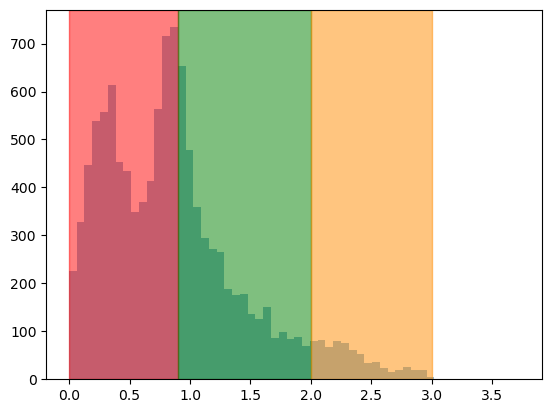

In [34]:
plt.hist(data.PIPELINE_Z,bins='auto',alpha=0.5);
plt.axvspan(0,0.9, color='red', alpha=0.5)
plt.axvspan(0.9,2, color='green', alpha=0.5)
plt.axvspan(2,3, color='darkorange', alpha=0.5)
plt.show()

# Bin 1: 0 <= Z <= 0.9

In [35]:
data = data[data.PIPELINE_Z<=0.9]

In [36]:
Fluxes = np.array([i for i in data.FLUX_ORIG]).byteswap().newbyteorder()
Wavelengths = np.array([i for i in data.WAVE_ORIG]).byteswap().newbyteorder()

new_wavs = np.arange(3600, 5159, 2)

def flux_processor(flux, wavelength,wl):
        flux_resampled = resample_spectra(new_wavs=new_wavs, spec_wavs=wavelength, savgol_data=flux)
        flux_smooth = savgol_smooth(flux_resampled, window_length=wl, polyorder=3)
        flux_smooth = flux_smooth/max(flux_smooth)

        return flux_smooth


clean_wavelength = [i/(j+1) for i,j in zip(Wavelengths,data.PIPELINE_Z)]
clearn_fluxes = [flux_processor(i,j,10) for i,j in zip(Fluxes,clean_wavelength)]
df = pd.DataFrame(clearn_fluxes,columns=new_wavs)
df['ZC'] = np.array(data.CORRECT_Z).byteswap().newbyteorder()
df['ZP'] = np.array(data.PIPELINE_Z).byteswap().newbyteorder()
df['STC'] = np.array(data.CORRECT_SPECTYPE).byteswap().newbyteorder()
df['STP'] = np.array(data.PIPELINE_SPECTYPE).byteswap().newbyteorder()
df['SPEC_TARGET'] = np.array(data.SPEC_TARGET).byteswap().newbyteorder()

df = df.dropna().reset_index(drop=True)

df['ID'] = range(1, len(df) + 1)

/tmp/ipykernel_137656/622763436.py:9: RuntimeWarning:

invalid value encountered in divide



In [37]:
pca = PCA(n_components=20)
pca_df = pd.DataFrame(pca.fit_transform(df.iloc[:,:-6]))
pca_df['ID'] = df['ID']

pca_df['STC'] = df['STC']
pca_df['STP'] = df['STP']

stars = pca_df[pca_df['STC'] == 'STAR']
galaxies = pca_df[pca_df['STC'] == 'GALAXY']
qsos = pca_df[pca_df['STC'] == 'QSO']
mismatched_qso = qsos[qsos['STC'] != qsos['STP']]

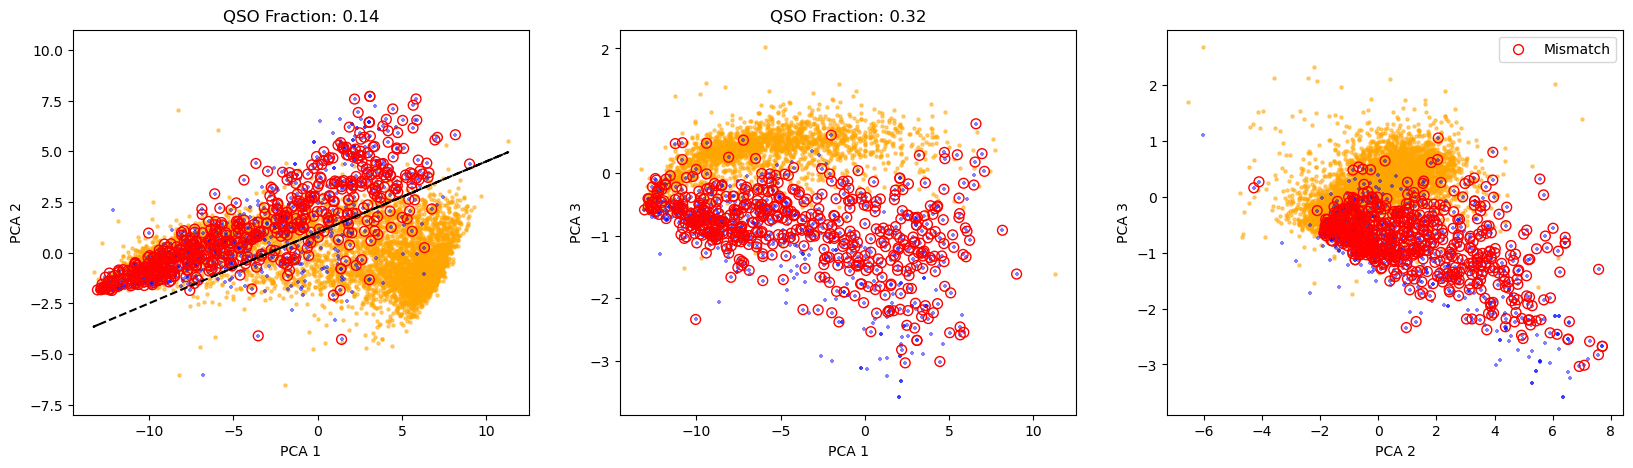

In [38]:
pca_df['STC'] = df['STC']
pca_df['STP'] = df['STP']

stars = pca_df[pca_df['STC'] == 'STAR']
galaxies = pca_df[pca_df['STC'] == 'GALAXY']
qsos = pca_df[pca_df['STC'] == 'QSO']
mismatched_qso = qsos[qsos['STC'] != qsos['STP']]

import matplotlib.pyplot as plt

# Define the cut-off line: y = -0.35 * PCA1 - 1

pca_df_filtered = pca_df[pca_df[1] > (0.35 * pca_df[0] + 1)]
# Apply filter: Keep only points where PCA 2 is below the line
filtered_galaxies = pca_df_filtered[pca_df_filtered['STC'] == 'GALAXY']
filtered_qsos = pca_df_filtered[pca_df_filtered['STC'] == 'QSO']
filtered_mismatched_qso = filtered_qsos[filtered_qsos['STC'] != filtered_qsos['STP']]

plt.subplots(1, 3, figsize=(20, 5))

# Subplot 1: PCA 1 vs PCA 2
plt.subplot(1, 3, 1)
plt.scatter(galaxies[0], galaxies[1], marker='o', alpha=0.5, color='orange', s=5)
plt.scatter(qsos[0], qsos[1], marker='+', alpha=0.5, color='blue', s=5)
plt.scatter(mismatched_qso[0], mismatched_qso[1], facecolors='none', edgecolors='red', s=50, label='Mismatch')
x = galaxies[0]
y = x * 0.35 +1
plt.plot(x, y, color='black', linestyle='--')  # Plot separation line
plt.ylim(-8, 11)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title(f'QSO Fraction: {len(qsos)/len(pca_df):.2f}')

# Subplot 2: PCA 1 vs PCA 3 (filtered by PCA 2 cut)
plt.subplot(1, 3, 2)
plt.scatter(filtered_galaxies[0], filtered_galaxies[2], marker='o', alpha=0.5, color='orange', s=5)
plt.scatter(filtered_qsos[0], filtered_qsos[2], marker='+', alpha=0.5, color='blue', s=5)
plt.scatter(filtered_mismatched_qso[0], filtered_mismatched_qso[2], facecolors='none', edgecolors='red', s=50, label='Mismatch')
plt.xlabel('PCA 1')
plt.ylabel('PCA 3')
plt.title(f'QSO Fraction: {len(qsos)/len(pca_df_filtered):.2f}')

# Subplot 3: PCA 2 vs PCA 3
plt.subplot(1, 3, 3)
plt.scatter(galaxies[1], galaxies[2], marker='o', alpha=0.5, color='orange', s=5)
plt.scatter(qsos[1], qsos[2], marker='+', alpha=0.5, color='blue', s=5)
plt.scatter(mismatched_qso[1], mismatched_qso[2], facecolors='none', edgecolors='red', s=50, label='Mismatch')
plt.xlabel('PCA 2')
plt.ylabel('PCA 3')

plt.legend()
plt.show()

In [41]:
import plotly.express as px
import pandas as pd

# Create a DataFrame with PCA components and labels
fig = px.scatter_3d(
    pca_df, 
    x=0, 
    y=1, 
    z=2, 
    color="STC",  # Color by Spectral Type Classification
    #symbol="STP",  # Different symbols for predicted spectral type
    opacity=0.7,
    title="3D PCA Scatter Plot",
    labels={0: "PCA 1", 1: "PCA 2", 2: "PCA 3"},
)

# Highlight mismatched QSOs
fig.add_trace(
    px.scatter_3d(
        mismatched_qso, 
        x=0, 
        y=1, 
        z=2, 
        color_discrete_sequence=["blue"], 
        symbol_sequence=["diamond"], 
        opacity=1
    ).data[0]
)

fig.update_traces(marker=dict(size=5))

import numpy as np
import plotly.graph_objects as go

# Define plane dimensions
x_range = np.linspace(pca_df[0].min(), pca_df[0].max(), 10)
y_range = np.linspace(pca_df[1].min(), pca_df[1].max(), 10)
X, Y = np.meshgrid(x_range, y_range)
Z = np.zeros_like(X)  # Initial plane at PCA 2 = 0

# Rotation angles
theta_x = np.pi / 5.142  # 45 degrees in radians
theta_z = np.pi / 9  # 10 degrees in radians

# Step 1: Rotate about X-axis (affects Y and Z)
Y_rot_x = Y * np.cos(theta_x) - Z * np.sin(theta_x)
Z_rot_x = Y * np.sin(theta_x) + Z * np.cos(theta_x)

# Step 2: Rotate about Z-axis (affects X and Y)
X_rot = X * np.cos(theta_z) - Y_rot_x * np.sin(theta_z)
Y_rot = X * np.sin(theta_z) + Y_rot_x * np.cos(theta_z)

# Create plane trace
plane_trace = go.Surface(
    x=X_rot, 
    y=Y_rot, 
    z=Z_rot_x, 
    colorscale=[(0, "black"), (1, "black")],  
    showscale=False,
    opacity=1
)

# Add the rotated plane to the figure
fig.add_trace(plane_trace)

# Define plane dimensions
x_range = np.linspace(pca_df[0].min(), pca_df[0].max(), 10)
y_range = np.linspace(pca_df[1].min(), pca_df[1].max(), 10)
X, Y = np.meshgrid(x_range, y_range)
Z = np.zeros_like(X)  # Initial plane at PCA 2 = 0

# Rotation angles
theta_x = np.pi / -9  # 45 degrees in radians
theta_z = np.pi / 9  # 10 degrees in radians

# Step 1: Rotate about X-axis (affects Y and Z)
Y_rot_x = Y * np.cos(theta_x) - Z * np.sin(theta_x)
Z_rot_x = Y * np.sin(theta_x) + Z * np.cos(theta_x)

# Step 2: Rotate about Z-axis (affects X and Y)
X_rot = X * np.cos(theta_z) - Y_rot_x * np.sin(theta_z)
Y_rot = X * np.sin(theta_z) + Y_rot_x * np.cos(theta_z)

# Create plane trace
plane_trace = go.Surface(
    x=X_rot, 
    y=Y_rot, 
    z=Z_rot_x+1, 
    colorscale=[(0, "black"), (1, "black")],  
    showscale=False,
    opacity=1
)

# Add the rotated plane to the figure
fig.add_trace(plane_trace)

fig.show()


In [40]:
import plotly.express as px
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Extract PCA components
X_pts = pca_df[0].values
Y_pts = pca_df[1].values
Z_pts = pca_df[2].values

# Rotation angles
#theta_x = np.pi / 5.142  # 45 degrees
#theta_z = np.pi / 18  # 10 degrees

# Original normal vector (before rotation)
normal = np.array([0, 0, 1])  # Plane was originally Z = 0

# Step 1: Rotate normal vector about X-axis
rotation_x = np.array([
    [1, 0, 0],
    [0, np.cos(theta_x), -np.sin(theta_x)],
    [0, np.sin(theta_x), np.cos(theta_x)]
])
normal_x_rotated = np.dot(rotation_x, normal)

# Step 2: Rotate normal vector about Z-axis
rotation_z = np.array([
    [np.cos(theta_z), -np.sin(theta_z), 0],
    [np.sin(theta_z), np.cos(theta_z), 0],
    [0, 0, 1]
])
normal_rotated = np.dot(rotation_z, normal_x_rotated)

# Extract the components of the final normal vector
N_x, N_y, N_z = normal_rotated

# Define a point on the plane (origin since the plane passes through (0,0,0))
d = 0  # Plane passes through the origin in PCA space

# Compute signed distance for each point
signed_distance = N_x * X_pts + N_y * Y_pts + N_z * Z_pts - d

# Mask for above/below the plane
above_plane_mask = signed_distance > 0
below_plane_mask = ~above_plane_mask

# Create two separate DataFrames
above_plane_df = pca_df[above_plane_mask]
below_plane_df = pca_df[below_plane_mask]

# Create 3D scatter plot for points above the plane
fig_above = px.scatter_3d(
    above_plane_df, 
    x=0, 
    y=1, 
    z=2, 
    color="STC",
    opacity=0.7,
    title="PCA Points Above the Plane",
    labels={0: "PCA 1", 1: "PCA 2", 2: "PCA 3"}
)

# Create 3D scatter plot for points below the plane
fig_below = px.scatter_3d(
    below_plane_df, 
    x=0, 
    y=1, 
    z=2, 
    color="STC",
    opacity=0.7,
    title="PCA Points Below the Plane",
    labels={0: "PCA 1", 1: "PCA 2", 2: "PCA 3"}
)

# Show the two figures separately
fig_above.show()
fig_below.show()


In [26]:
above_plane_df['STC'].value_counts()

STC
GALAXY    3434
QSO         47
STAR        29
Name: count, dtype: int64

In [27]:
below_plane_df['STC'].value_counts()

STC
GALAXY    2324
QSO        907
STAR        14
Name: count, dtype: int64

# Second Plane

In [28]:
# Create a DataFrame with PCA components and labels

pca_df = below_plane_df
fig = px.scatter_3d(
    pca_df, 
    x=0, 
    y=1, 
    z=2, 
    color="STC",  # Color by Spectral Type Classification
    #symbol="STP",  # Different symbols for predicted spectral type
    opacity=0.7,
    title="3D PCA Scatter Plot",
    labels={0: "PCA 1", 1: "PCA 2", 2: "PCA 3"},
)

# Highlight mismatched QSOs
fig.add_trace(
    px.scatter_3d(
        mismatched_qso, 
        x=0, 
        y=1, 
        z=2, 
        color_discrete_sequence=["red"], 
        symbol_sequence=["diamond"], 
        opacity=1
    ).data[0]
)

fig.update_traces(marker=dict(size=5))

import numpy as np
import plotly.graph_objects as go

# Define plane dimensions
x_range = np.linspace(pca_df[0].min(), pca_df[0].max(), 10)
y_range = np.linspace(pca_df[1].min(), pca_df[1].max(), 10)
X, Y = np.meshgrid(x_range, y_range)
Z = np.zeros_like(X)  # Initial plane at PCA 2 = 0

# Rotation angles
theta_x = np.pi / -9  # 45 degrees in radians
theta_z = np.pi / 9  # 10 degrees in radians

# Step 1: Rotate about X-axis (affects Y and Z)
Y_rot_x = Y * np.cos(theta_x) - Z * np.sin(theta_x)
Z_rot_x = Y * np.sin(theta_x) + Z * np.cos(theta_x)

# Step 2: Rotate about Z-axis (affects X and Y)
X_rot = X * np.cos(theta_z) - Y_rot_x * np.sin(theta_z)
Y_rot = X * np.sin(theta_z) + Y_rot_x * np.cos(theta_z)

# Create plane trace
plane_trace = go.Surface(
    x=X_rot, 
    y=Y_rot, 
    z=Z_rot_x+1, 
    colorscale=[(0, "black"), (1, "black")],  
    showscale=False,
    opacity=1
)

# Add the rotated plane to the figure
fig.add_trace(plane_trace)

fig.show()


In [29]:
import plotly.express as px
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Extract PCA components
X_pts = pca_df[0].values
Y_pts = pca_df[1].values
Z_pts = pca_df[2].values

# Rotation angles
#theta_x = np.pi / 5.142  # 45 degrees
#theta_z = np.pi / 9  # 10 degrees

# Original normal vector (before rotation)
normal = np.array([0, 0, 1])  # Plane was originally Z = 0

# Step 1: Rotate normal vector about X-axis
rotation_x = np.array([
    [1, 0, 0],
    [0, np.cos(theta_x), -np.sin(theta_x)],
    [0, np.sin(theta_x), np.cos(theta_x)]
])
normal_x_rotated = np.dot(rotation_x, normal)

# Step 2: Rotate normal vector about Z-axis
rotation_z = np.array([
    [np.cos(theta_z), -np.sin(theta_z), 0],
    [np.sin(theta_z), np.cos(theta_z), 0],
    [0, 0, 1]
])
normal_rotated = np.dot(rotation_z, normal_x_rotated)

# Extract the components of the final normal vector
N_x, N_y, N_z = normal_rotated

# Define a point on the plane (origin since the plane passes through (0,0,0))
d = 1  # Plane passes through the origin in PCA space

# Compute signed distance for each point
signed_distance = N_x * X_pts + N_y * Y_pts + N_z * Z_pts - d

# Mask for above/below the plane
above_plane_mask = signed_distance > 0
below_plane_mask = ~above_plane_mask

# Create two separate DataFrames
above_plane_df = pca_df[above_plane_mask]
below_plane_df = pca_df[below_plane_mask]

# Create 3D scatter plot for points above the plane
fig_above = px.scatter_3d(
    above_plane_df, 
    x=0, 
    y=1, 
    z=2, 
    color="STC",
    opacity=0.7,
    title="PCA Points Above the Plane",
    labels={0: "PCA 1", 1: "PCA 2", 2: "PCA 3"}
)

# Create 3D scatter plot for points below the plane
fig_below = px.scatter_3d(
    below_plane_df, 
    x=0, 
    y=1, 
    z=2, 
    color="STC",
    opacity=0.7,
    title="PCA Points Below the Plane",
    labels={0: "PCA 1", 1: "PCA 2", 2: "PCA 3"}
)

# Show the two figures separately
fig_above.show()
fig_below.show()


In [30]:
above_plane_df['STC'].value_counts()

STC
GALAXY    1499
QSO         22
STAR         5
Name: count, dtype: int64

In [31]:
below_plane_df['STC'].value_counts()

STC
QSO       885
GALAXY    825
STAR        9
Name: count, dtype: int64